<a href="https://colab.research.google.com/github/carolmarquezini/preta_lab/blob/main/pojeto03_bibliotecas_python.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# PROJETO 3: BIBLIOTECAS PYTHON PARA ANÁLISE DE DADOS

## Objetivos

 1. *Introduzir as principais bibliotecas de Python para análise de dados:*
 Explorar bibliotecas amplamente utilizadas, como Pandas, NumPy e Matplotlib, e suas aplicações no tratamento de dados.

2. *Demonstrar o uso prático das bibliotecas para análise de dados:* Aplicar essas ferramentas em processos de manipulação, visualização e análise de dados reais.

3. *Praticar com dados da PNAD Contínua de 2024 (2º semestre):* Usar os dados da Pesquisa Nacional por Amostra de Domicílios (PNAD) Contínua, que investiga aspectos socioeconômicos da população brasileira, como educação, trabalho, e habitação, para simular análises de políticas públicas e entender o impacto de diferentes variáveis.

4. *Aplicar métodos avançados de análise com bibliotecas Python:* Implementar técnicas mais sofisticadas de análise para extrair insights profundos dos dados e explorar agrupamentos,função lambda, tendências e médias.

## Cenário

PNAD CONTINUA DE 2024 - 2 TRIMESTRE (ABR-MAIO-JUN)

Dados Brasil:  Com todos os estados

Dados Educação: A base de dados tem apenas dados demográficos e perguntas sobre educação.

Filtros iniciais:

1. Idade entre 18 e 90 anos

 - **OBJETIVO**

Entender como está o comportamento dos millenials brasileiros, também conhecida como geração Y, quando o cenário é educação.

### O que você precisa fazer no Projeto 3

#### ETAPA 1: Carregar arquivos

1. Carregar os arquivos 'PNAD24_EDUCACAO.csv', 'dicionario_colunas' com pandas

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [4]:
%cd /content/drive/MyDrive/pretaLab-ciclo11/projeto03/
! ls

/content/drive/MyDrive/pretaLab-ciclo11/projeto03
dicionario_colunas.xlsx  dicionario_dados.xlsx	PNAD24_EDUCACAO.csv  Pojeto3.ipynb


In [31]:
# Carregar os arquivos 'PNAD24_EDUCACAO.csv', 'dicionario_colunas.xlsx' com pandas
import pandas as pd

def carregar_dados_csv(arquivo_csv):
    # Carregar o arquivo CSV
    df_csv = pd.read_csv(arquivo_csv, delimiter=',')

    return df_csv

def carregar_dados_excel( arquivo_excel):
    # Carregar o arquivo Excel
    df_excel = pd.read_excel(arquivo_excel, engine='openpyxl')

    return df_excel

df_csv = carregar_dados_csv('PNAD24_EDUCACAO.csv')
df_excel = carregar_dados_excel('dicionario_colunas.xlsx')

In [ ]:
print(df_csv.head())
print(df_excel.head())

 #### ETAPA 2: Tratamento e Limpeza de Dados

 1. Filtrar os dados para idade entre 18 e 35 anos - faixa etaria da geração Y


In [68]:
print(df_csv.columns)

Index(['ano', 'trimestre', 'sigla_uf', 'sigla_uf_nome', 'id_pessoa', 'V2007',
       'V2009', 'V2010', 'V3001', 'V3002', 'V3002A', 'V3003', 'V3003A',
       'V3004', 'V3005', 'V3005A', 'V3006', 'V3006A', 'V3007', 'V3008',
       'V3009', 'V3009A', 'V3010', 'V3011', 'V3011A', 'V3012', 'V3013',
       'V3013A', 'V3013B', 'V3014'],
      dtype='object')


In [49]:
# Remover linhas onde a coluna de idade (V2009) tenha valores nulos
df_limpo = df_csv.dropna(subset=['V2009'])

In [50]:
# Filtrar para idades entre 18 e 35 anos
df_filtrado = df_limpo[(df_limpo['V2009'] >= 18) & (df_limpo['V2009'] <= 35)]

In [51]:
# Exibir o DataFrame filtrado
print(df_filtrado)

         ano  trimestre sigla_uf        sigla_uf_nome        id_pessoa  \
0       2024          2       AP                Amapá  160000321011101   
1       2024          2       AP                Amapá  160000321021101   
2       2024          2       AP                Amapá  160000321021102   
3       2024          2       AP                Amapá  160000321031104   
5       2024          2       AP                Amapá  160000321031103   
...      ...        ...      ...                  ...              ...   
363960  2024          2       RN  Rio Grande do Norte  240086301071101   
363961  2024          2       RN  Rio Grande do Norte  240086301071102   
363964  2024          2       RN  Rio Grande do Norte  240086301091101   
363967  2024          2       RN  Rio Grande do Norte  240086301121103   
363972  2024          2       RN  Rio Grande do Norte  240086301131105   

         V2007  V2009  V2010  V3001  V3002  ...  V3009  V3009A  V3010  V3011  \
0       Mulher     27      4   

 2. tratar os valores das colunas conforme o dicionario de dados:

    sexo,
    idade,
    raça,
    sabe_ler_escrever


In [82]:
# Mapeamento para as colunas conforme o dicionário de dados
sexo_mapping = {'Homem': 'Homem', 'Mulher': 'Mulher'}
raca_mapping = {
    1: 'Branca',
    2: 'Preta',
    3: 'Amarela',
    4: 'Parda',
    5: 'Indígena',
    9: 'Ignorado'
}
sabe_ler_escrever_mapping = {1: 'Sim', 2: 'Não'}

In [114]:
# Aplicar os mapeamentos
df_filtrado.loc[:,'Sexo'] = df_filtrado['V2007'].map(sexo_mapping)
df_filtrado.loc[:,'Raça'] = df_filtrado['V2010'].map(raca_mapping)
df_filtrado.loc[:, 'Sabe ler e escrever'] = df_filtrado['V3001'].map(sabe_ler_escrever_mapping)


In [115]:
# Selecionar as colunas de interesse
df_resultado = df_filtrado[['id_pessoa', 'Sexo', 'V2009', 'Raça', 'Sabe ler e escrever']]

In [116]:
# Exibir o DataFrame tratado
print(df_resultado)

              id_pessoa    Sexo  V2009    Raça Sabe ler e escrever
0       160000321011101  Mulher     27   Parda                 Sim
1       160000321021101  Mulher     33   Parda                 Sim
2       160000321021102   Homem     27   Parda                 Sim
3       160000321031104  Mulher     27  Branca                 Sim
5       160000321031103   Homem     23   Parda                 Sim
...                 ...     ...    ...     ...                 ...
363960  240086301071101   Homem     30  Branca                 Sim
363961  240086301071102  Mulher     35  Branca                 Sim
363964  240086301091101  Mulher     28  Branca                 Sim
363967  240086301121103  Mulher     31   Parda                 Sim
363972  240086301131105  Mulher     28  Branca                 Sim

[117580 rows x 5 columns]



 3. transformar a coluna idade em faixa etaria conforme o intervalo: 18-23, 24-29 e 30-35.

In [117]:
# Criar faixas etárias
faixas_etarias = [17, 23, 29, 35]  # 17 é usado para incluir 18 na primeira faixa
nomes_faixas = ['18-23', '24-29', '30-35']

# Criar uma nova coluna 'Faixa Etária'
df_resultado.loc[:,'Faixa Etária'] = pd.cut(df_resultado.loc[:,'V2009'], bins=faixas_etarias, labels=nomes_faixas)

# Exibir o DataFrame com a nova coluna de faixa etária
print(df_resultado)

              id_pessoa    Sexo  V2009    Raça Sabe ler e escrever  \
0       160000321011101  Mulher     27   Parda                 Sim   
1       160000321021101  Mulher     33   Parda                 Sim   
2       160000321021102   Homem     27   Parda                 Sim   
3       160000321031104  Mulher     27  Branca                 Sim   
5       160000321031103   Homem     23   Parda                 Sim   
...                 ...     ...    ...     ...                 ...   
363960  240086301071101   Homem     30  Branca                 Sim   
363961  240086301071102  Mulher     35  Branca                 Sim   
363964  240086301091101  Mulher     28  Branca                 Sim   
363967  240086301121103  Mulher     31   Parda                 Sim   
363972  240086301131105  Mulher     28  Branca                 Sim   

       Faixa Etária  
0             24-29  
1             30-35  
2             24-29  
3             24-29  
5             18-23  
...             ...  
36396

<ipython-input-117-b4b18100b378>:6: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_resultado.loc[:,'Faixa Etária'] = pd.cut(df_resultado.loc[:,'V2009'], bins=faixas_etarias, labels=nomes_faixas)


#### ETAPA 3: Análise

 1.  Qual volume de pessoas que sabem ler e escrever?
   - Faça uma contagem na coluna e mostre o resultado como um gráfico de barras do matplotlib

In [118]:
import matplotlib.pyplot as plt

In [119]:
# Contar o número de pessoas que sabem ler e escrever
contagem = df_filtrado['Sabe ler e escrever'].value_counts()

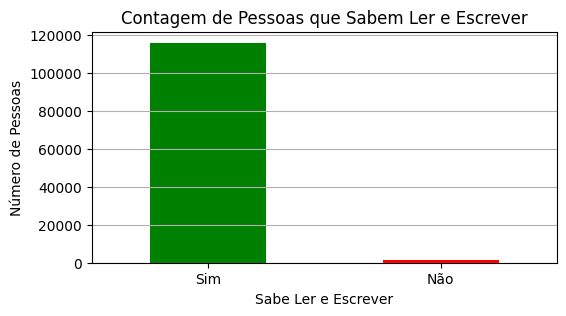

In [120]:
# Criar um gráfico de barras
plt.figure(figsize=(6, 3))
contagem.plot(kind='bar', color=['GREEN', 'RED'])
plt.title('Contagem de Pessoas que Sabem Ler e Escrever')
plt.xlabel('Sabe Ler e Escrever')
plt.ylabel('Número de Pessoas')
plt.xticks(rotation=0)  # Manter os rótulos na horizontal
plt.grid(axis='y')  # Adicionar uma grade no eixo y
plt.show()


2.  Como é a distribuição Brasil da geração Y pesquisada?

  - Agrupe a coluna sexo,raca, faixa_etaria,sigla_uf e sabe_ler_escrever fazendo a contagem desse agrupamento, salve em um dataframe o resultado.


In [121]:
# Agrupar os dados e contar as ocorrências
resultado_agrupado = df_filtrado.groupby(
    ['Sexo', 'Raça', 'Faixa Etária', 'sigla_uf', 'Sabe ler e escrever'],
    observed=False
).size().reset_index(name='Contagem')

# Exibir o DataFrame resultado
print(resultado_agrupado)

# Salvar o resultado em um arquivo CSV, se necessário
resultado_agrupado.to_csv('distribuicao_geracao_y.csv', index=False)

        Sexo     Raça Faixa Etária sigla_uf Sabe ler e escrever  Contagem
0      Homem  Amarela        18-23       AC                 Não         0
1      Homem  Amarela        18-23       AC                 Sim         0
2      Homem  Amarela        18-23       AL                 Não         0
3      Homem  Amarela        18-23       AL                 Sim         5
4      Homem  Amarela        18-23       AM                 Não         0
...      ...      ...          ...      ...                 ...       ...
1939  Mulher    Preta        30-35       SE                 Sim        41
1940  Mulher    Preta        30-35       SP                 Não         2
1941  Mulher    Preta        30-35       SP                 Sim       126
1942  Mulher    Preta        30-35       TO                 Não         0
1943  Mulher    Preta        30-35       TO                 Sim        30

[1944 rows x 6 columns]


3. Filtre o dataframe do ponto 2 para apenas os que lê e escreve, salve o resultado em novo dataframe.


In [126]:
# Filtrar o DataFrame para apenas aqueles que sabem ler e escrever
df_leitores_escritores = resultado_agrupado[resultado_agrupado['Sabe ler e escrever'] == 'Sim'].copy()

print(df_leitores_escritores[['Sexo', 'Contagem']].groupby('Sexo').sum())

# Exibir o novo DataFrame
print(df_leitores_escritores.head())


        Contagem
Sexo            
Homem      56821
Mulher     59244
    Sexo     Raça Faixa Etária sigla_uf Sabe ler e escrever  Contagem
1  Homem  Amarela        18-23       AC                 Sim         0
3  Homem  Amarela        18-23       AL                 Sim         5
5  Homem  Amarela        18-23       AM                 Sim         1
7  Homem  Amarela        18-23       AP                 Sim         0
9  Homem  Amarela        18-23       BA                 Sim         1


In [125]:
# Verifique a contagem de leitores e escritores por sexo
print(resultado_agrupado[resultado_agrupado['Sabe ler e escrever'] == 'Sim'][['Sexo', 'Contagem']].groupby('Sexo').sum())

# Visualize o DataFrame filtrado
print(df_leitores_escritores)

# Verifique se existem contagens zero
print(resultado_agrupado[resultado_agrupado['Sabe ler e escrever'] == 'Sim'][['Sexo', 'Contagem']])

# Verifique o mapeamento
print(df_filtrado['V3001'].value_counts())


        Contagem
Sexo            
Homem      56821
Mulher     59244
        Sexo     Raça Faixa Etária sigla_uf Sabe ler e escrever  Contagem
1      Homem  Amarela        18-23       AC                 Sim         0
3      Homem  Amarela        18-23       AL                 Sim         5
5      Homem  Amarela        18-23       AM                 Sim         1
7      Homem  Amarela        18-23       AP                 Sim         0
9      Homem  Amarela        18-23       BA                 Sim         1
...      ...      ...          ...      ...                 ...       ...
1935  Mulher    Preta        30-35       RS                 Sim        57
1937  Mulher    Preta        30-35       SC                 Sim        60
1939  Mulher    Preta        30-35       SE                 Sim        41
1941  Mulher    Preta        30-35       SP                 Sim       126
1943  Mulher    Preta        30-35       TO                 Sim        30

[972 rows x 6 columns]
        Sexo  Contag


4. Como é o comportamento de homens brancos e mulheres negras no  Brasil da geração Y pesquisada na faixa etária 18-23 que lê e escreve?

 - Faça um gráfico de barras horizontais para cada gênero filtrado pela raça de cada gênero, em que o eixo y é a sigla dos estados e o eixo x  o volume

 #dica: para filtrar o dataframe e fazer gráfico vc pode usar o método:

 df[((df_novo['coluna1'] == valor_filtro) & (df['coluna2'] == valor_filtro) & (df['coluna'] == valor_filtro))].plot(kind='barh', x='coluna1', y='contagem')


In [130]:
# Filtrar o dataframe para homens brancos de 18-23 anos que sabem ler e escrever
df_homens_brancos = resultado_agrupado[
    (resultado_agrupado['Sexo'] == 'Homem') &
    (resultado_agrupado['Raça'] == 'Branca') &
    (resultado_agrupado['Faixa Etária'] == '18-23') &
    (resultado_agrupado['Sabe ler e escrever'] == 'Sim')
]

# Filtrar o dataframe para mulheres negras de 18-23 anos que sabem ler e escrever
df_mulheres_negras = resultado_agrupado[
    (resultado_agrupado['Sexo'] == 'Mulher') &
    (resultado_agrupado['Raça'] == 'Preta') &
    (resultado_agrupado['Faixa Etária'] == '18-23') &
    (resultado_agrupado['Sabe ler e escrever'] == 'Sim')
]


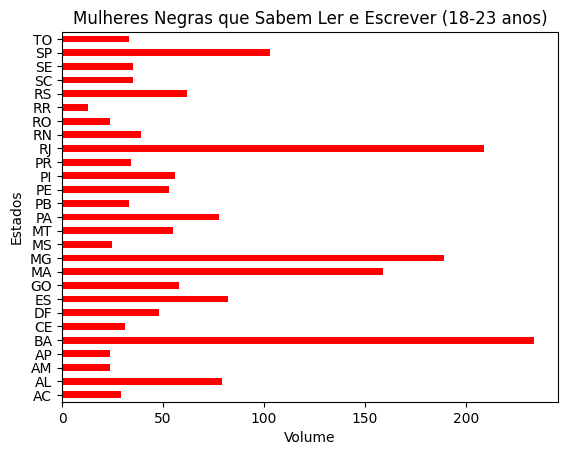

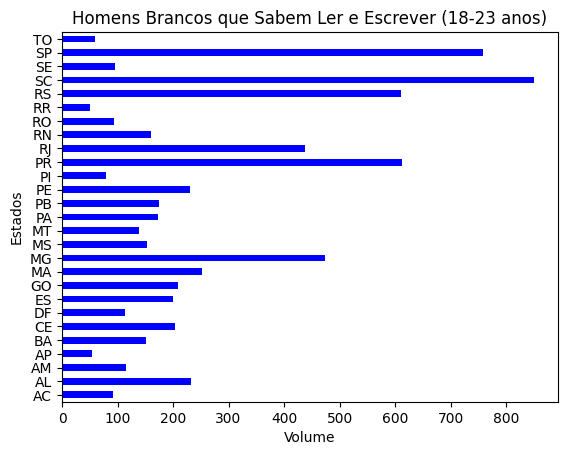

In [131]:
# Gráfico para mulheres negras
df_mulheres_negras.plot(kind='barh', x='sigla_uf', y='Contagem', color='red', legend=False)
plt.title('Mulheres Negras que Sabem Ler e Escrever (18-23 anos)')
plt.xlabel('Volume')
plt.ylabel('Estados')
plt.show()

# Gráfico para homens brancos
df_homens_brancos.plot(kind='barh', x='sigla_uf', y='Contagem', color='blue', legend=False)
plt.title('Homens Brancos que Sabem Ler e Escrever (18-23 anos)')
plt.xlabel('Volume')
plt.ylabel('Estados')
plt.show()



 5. Escreva uma conclusão do insights que encontrou no ponto 4 (OPCIONAL)